In [20]:
from pyKoLesky import * 
import torch
import timeit
from matplotlib import pyplot

In [57]:
rho = 2
n = 500
d = 2

In [59]:
rng = torch.Generator().manual_seed(7)
x = torch.rand(n,d,generator=rng) 
Perm,lengths = maximin(x) 
sparsity = sparsity_pattern(x[Perm], lengths, rho)
print("reduce from %d to %d elements"%(n*(1+n)//2,sum([len(v) for v in sparsity.values()])))

reduce from 125250 to 2246 elements


In [60]:
bss = [2**i for i in range(9)]
times_batched = torch.zeros(len(bss))
times_looped = torch.zeros(len(bss))
for i,bs in enumerate(bss):
    L = torch.rand([bs,n,n],generator=rng).tril()
    Theta = torch.einsum("...jk,...lk->...jl",L,L)
    Theta[...,torch.arange(n),torch.arange(n)] = Theta[...,torch.arange(n),torch.arange(n)]+1e-3 # nugget term 
    # batched 
    t0 = timeit.default_timer()
    U = sparse_cholesky_dense(Theta, Perm, sparsity)
    times_batched[i] = timeit.default_timer()-t0 
    # looped 
    t0 = timeit.default_timer()
    for j in range(Theta.size(0)):
        U_j = sparse_cholesky_dense(Theta[j], Perm, sparsity)
    times_looped[i] = timeit.default_timer()-t0
print(times_batched,times_looped)

tensor([0.0420, 0.0350, 0.0388, 0.0414, 0.0398, 0.0955, 0.0623, 0.1155, 0.2281]) tensor([0.0331, 0.0656, 0.1291, 0.3093, 0.5661, 1.0973, 2.2660, 4.0378, 8.3322])


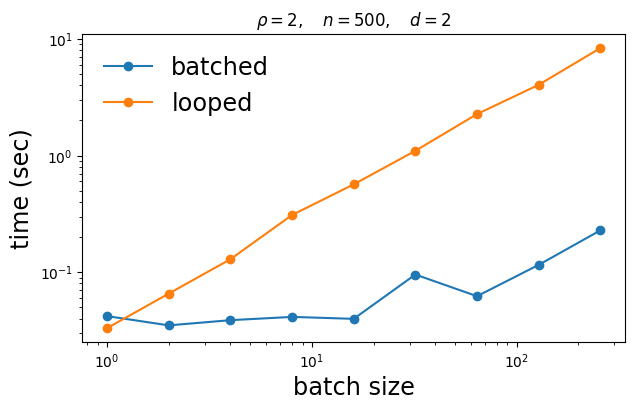

In [61]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(7,4))
ax.plot(bss,times_batched,'-o',label="batched")
ax.plot(bss,times_looped,'-o',label="looped")
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=10)
ax.set_xlabel("batch size",fontsize="xx-large")
ax.set_ylabel("time (sec)",fontsize="xx-large")
ax.legend(fontsize="xx-large",frameon=False)
ax.set_title(r"$\rho = %d, \quad n = %d, \quad d = %d$"%(rho,n,d));